# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Fadil Alfarizzi  
**NIM:** 123450048  
**Kelas:** RC  
**Tanggal:** 2026-09-22  

**Berkas pengumpulan:** `M01_123450048.ipynb`, `M01_123450048.pdf`, dan `M01_123450048_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [1]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '123450048'  # NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.11.15',
 'numpy': '2.4.4',
 'pandas': '3.0.2',
 'sklearn': '1.8.0',
 'torch': '2.14.0+cu130',
 'device': 'cpu',
 'seed': 1048}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter adalah nilai yang dipelajari dari data selama optimisasi, seperti bobot dan bias. Hyperparameter ditentukan sebelum atau di luar proses pembelajaran, seperti learning rate, ukuran hidden layer, batch size, jumlah epoch, dan pilihan aktivasi.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Komposisi dua transformasi affine tetap affine: $W_2(W_1x+b_1)+b_2=(W_2W_1)x+(W_2b_1+b_2)$. Tanpa fungsi nonlinier, lapisan kedua tidak menambah bentuk fungsi yang dapat direpresentasikan.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** Jika batch disimpan sebagai baris dengan shape `(B, 2)`, bobot pada `nn.Linear(2, 8)` memiliki shape `(8, 2)` dan bias memiliki shape `(8,)`.
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** Fungsi ini menggabungkan sigmoid dan binary cross-entropy secara numerik stabil, sehingga tidak perlu menghitung probabilitas sigmoid lebih dulu dan mengurangi risiko underflow/overflow.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Saya memperkirakan hidden size 16 memberi validation loss lebih rendah daripada hidden size 4 karena kapasitasnya lebih besar. Saya memperkirakan tanh atau sigmoid dapat bekerja stabil pada data yang sudah distandardisasi, sedangkan ReLU mungkin cepat turun tetapi dapat memiliki unit mati pada beberapa inisialisasi.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [2]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    # Sigmoid yang stabil untuk nilai positif/negatif besar.
    z = np.asarray(z, dtype=np.float64)
    result = np.empty_like(z)
    positive = z >= 0
    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z / (1.0 + exp_z)
    return result

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(np.asarray(z), 0.0)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    z = np.asarray(z)
    return np.where(z >= 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    # Validasi shape; hitung z dan a; kembalikan keduanya.
    X = np.asarray(X)
    w = np.asarray(w)
    if X.ndim != 2 or w.ndim != 1 or X.shape[1] != w.shape[0]:
        raise ValueError(f'shape tidak sesuai: X={X.shape}, w={w.shape}')
    z = X @ w + b
    return z, activation(z)

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


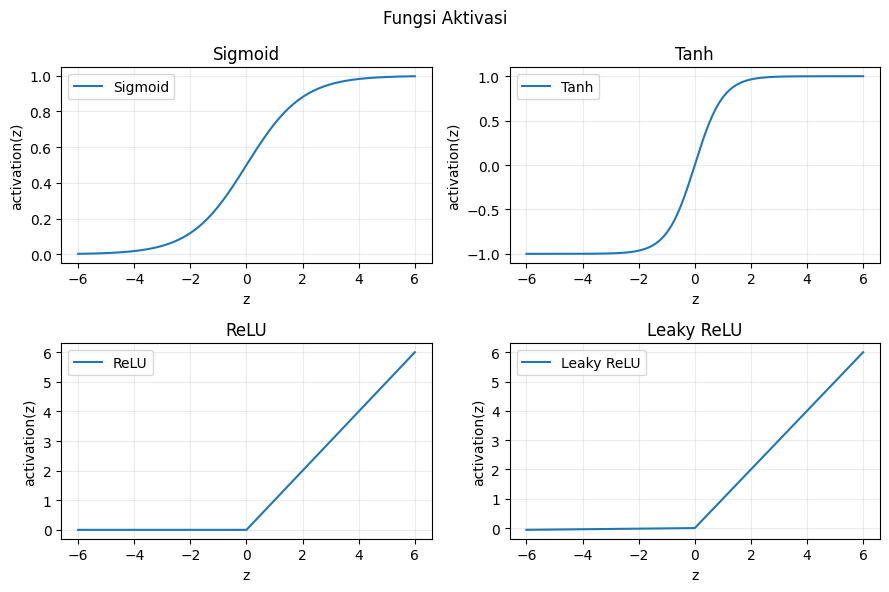

In [3]:
grid = np.linspace(-6, 6, 600)
# Kamus berisi empat aktivasi.
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

# Subplot 2x2. Setiap plot memiliki judul, label sumbu, dan grid.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values, label=name)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel('activation(z)')
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle('Fungsi Aktivasi')
fig.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: `tanh`, karena keluarannya berada pada rentang -1 sampai 1 dan simetris terhadap nol.
- Aktivasi yang tepat nol untuk masukan negatif: ReLU.
- Aktivasi yang mudah jenuh: sigmoid dan tanh pada nilai masukan dengan magnitudo besar.
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: satu transformasi linear hanya menghasilkan satu batas keputusan linear, sedangkan data `make_moons` memerlukan batas nonlinier.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [4]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

# Hitung z1, h, logit, probabilitas, dan BCE.
z1_np = x_manual @ W1.T + b1
h_np = relu_np(z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
bce_np = -np.mean(y_manual * np.log(prob_np) + (1 - y_manual) * np.log1p(-prob_np))

# Hitung parameter manual dari ukuran W1, b1, W2, b2.
parameter_count_manual = W1.size + b1.size + W2.size + b2.size

pd.DataFrame({
    'tensor': ['z1', 'h', 'logit', 'probabilitas', 'BCE', 'parameter'],
    'nilai': [z1_np.tolist(), h_np.tolist(), logit_np.tolist(),
              np.round(prob_np, 4).tolist(), round(float(bce_np), 4),
              parameter_count_manual],
})

,tensor,nilai
0,z1,"[[1.5, 1.0]]"
1,h,"[[1.5, 1.0]]"
2,logit,[[2.5]]
3,probabilitas,[[0.9241]]
4,BCE,0.0789
5,parameter,9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | `(1, 2)` | `[[2.0, -1.0]]` |
| $W^{(1)}$ | `(2, 2)` | tersedia pada kode |
| $z^{(1)}$ | `(1, 2)` | `[[1.5, 1.0]]` |
| $h$ | `(1, 2)` | `[[1.5, 1.0]]` |
| logit | `(1, 1)` | `[[2.5]]` |
| probabilitas | `(1, 1)` | `[[0.9241]]` |
| BCE | skalar | `0.0789` |

**Jumlah parameter dan perhitungannya:** $W^{(1)}$ berukuran $2\times2=4$, $b^{(1)}$ berisi 2, $W^{(2)}$ berukuran $1\times2=2$, dan $b^{(2)}$ berisi 1, sehingga totalnya `4 + 2 + 2 + 1 = 9` parameter.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [5]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# Salin W1, b1, W2, b2 menggunakan torch.no_grad().
with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

# Hitung torch_logit, torch_probability, dan torch_loss.
torch_logit = manual_model(torch.from_numpy(x_manual))
torch_probability = torch.sigmoid(torch_logit)
torch_loss = nn.functional.binary_cross_entropy_with_logits(torch_logit, torch.from_numpy(y_manual))

# Pemeriksaan.
assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np)) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual
pd.DataFrame({'numpy_logit': [float(logit_np.item())], 'torch_logit': [torch_logit.item()],
              'absolute_difference': [abs(torch_logit.item() - float(logit_np.item()))],
              'numpy_bce': [float(bce_np)], 'torch_bce': [torch_loss.item()]})

,numpy_logit,torch_logit,absolute_difference,numpy_bce,torch_bce
0,2.5,2.5,0.0,0.0789,0.0789


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** plot, tabel shape dan parameter, serta pencocokan NumPy-PyTorch sudah selesai; selisih logit dan BCE berada di bawah $10^{-6}$.

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


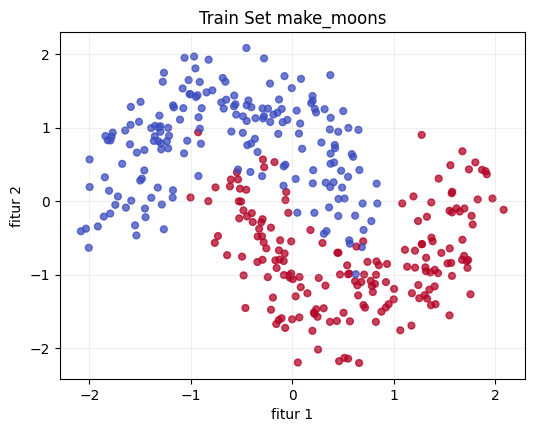

In [6]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Scaler hanya di-fit pada train set agar rata-rata dan simpangan baku validation/test tidak ikut memengaruhi representasi data saat pelatihan. Validation set dipakai untuk pemilihan model dan test set disimpan sampai evaluasi final. Jika scaler di-fit pada seluruh data, statistik test ikut bocor ke pipeline sehingga evaluasi akhir menjadi terlalu optimis.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [7]:
def activation_layer(name: str) -> nn.Module:
    # Kembalikan objek nn.ReLU(), nn.Tanh(), atau nn.Sigmoid().
    choices = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid}
    key = name.lower()
    if key not in choices:
        raise ValueError(f'aktivasi tidak dikenal: {name}')
    return choices[key]()

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    # Arsitektur 2 -> hidden_dim -> 1 tanpa sigmoid output.
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    ).to(DEVICE)
    return model

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

# Model 2 -> 8 -> 1: parameter 2h + h + h + 1 = 4h + 1 = 33.
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print('parameter model 2 -> 8 -> 1:', count_parameters(model_check))

parameter model 2 -> 8 -> 1: 33


In [8]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Digit terakhir NIM adalah 8, sehingga variasi individual menggunakan sigmoid. Saya memprediksi sigmoid akan lebih lambat daripada ReLU pada awal training, tetapi tetap menghasilkan validation loss yang kompetitif karena keluarannya halus.

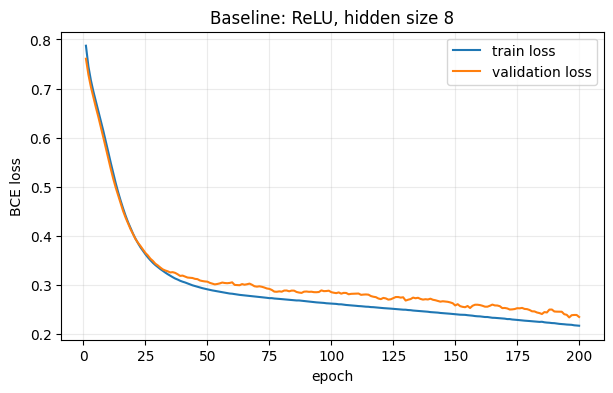

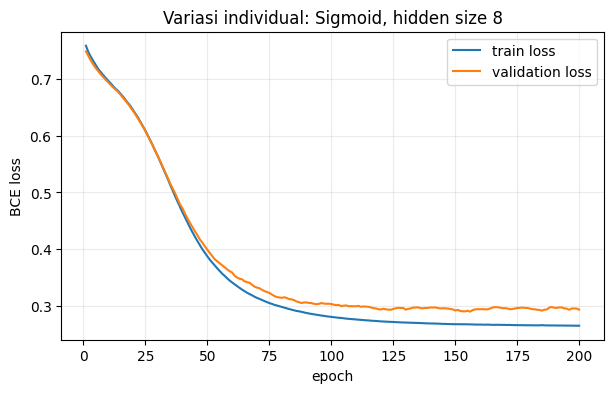

,run_id,val_loss,val_accuracy,runtime_seconds
0,baseline_relu_h8,0.2346,0.9167,1.6466
1,individual_sigmoid_h8,0.2933,0.8833,1.2922


In [9]:
# Latih baseline, tampilkan kurva train/validation loss, dan catat metrik.
# Latih satu variasi individual dengan komponen lain tetap.
def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history['epoch'], history['train_loss'], label='train loss')
    ax.plot(history['epoch'], history['val_loss'], label='validation loss')
    ax.set(title=title, xlabel='epoch', ylabel='BCE loss')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

baseline_model = build_model(8, 'relu')
baseline_history, baseline_runtime = train_model(baseline_model, seed=SEED)
individual_model = build_model(8, 'sigmoid')
individual_history, individual_runtime = train_model(individual_model, seed=SEED)
plot_history(baseline_history, 'Baseline: ReLU, hidden size 8')
plot_history(individual_history, 'Variasi individual: Sigmoid, hidden size 8')
baseline_metrics = evaluate(baseline_model, X_val_t, y_val_t)
individual_metrics = evaluate(individual_model, X_val_t, y_val_t)
pd.DataFrame([
    {'run_id': 'baseline_relu_h8', 'val_loss': baseline_metrics['loss'],
     'val_accuracy': baseline_metrics['accuracy'], 'runtime_seconds': baseline_runtime},
    {'run_id': 'individual_sigmoid_h8', 'val_loss': individual_metrics['loss'],
     'val_accuracy': individual_metrics['accuracy'], 'runtime_seconds': individual_runtime},
])

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [10]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

# Untuk setiap kombinasi:
# 1. buat model baru dengan seed yang sama;
# 2. latih dengan anggaran tetap;
# 3. evaluasi train dan validation;
# 4. simpan model/history;
# 5. tambahkan satu dictionary metrik ke experiment_rows.
for activation in ACTIVATIONS:
    for hidden_dim in HIDDEN_SIZES:
        run_id = f'{activation}_h{hidden_dim}'
        model = build_model(hidden_dim, activation, seed=SEED)
        history, runtime_seconds = train_model(
            model, epochs=EPOCHS, learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE, seed=SEED,
        )
        train_metrics = evaluate(model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
        val_metrics = evaluate(model, X_val_t, y_val_t)
        trained_models[run_id] = model
        histories[run_id] = history
        experiment_rows.append({
            'run_id': run_id,
            'module': 'M01',
            'student_id': NIM,
            'seed': SEED,
            'dataset': 'make_moons',
            'split': 'train-val-test',
            'model': f'FNN_2-{hidden_dim}-1',
            'optimizer': 'SGD',
            'learning_rate': LEARNING_RATE,
            'batch_size': BATCH_SIZE,
            'epochs': EPOCHS,
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
            'val_metric': val_metrics['accuracy'],
            'test_metric': np.nan,
            'parameters': count_parameters(model),
            'trainable_parameters': count_parameters(model),
            'runtime_seconds': runtime_seconds,
            'device': str(DEVICE),
            'notes': f'activation={activation}; hidden_size={hidden_dim}',
        })

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == 6
display(results[['run_id', 'model', 'train_loss', 'val_loss', 'val_metric',
                 'parameters', 'runtime_seconds']])
results.to_csv(f'M01_{NIM}_metrics.csv', index=False)

,run_id,model,train_loss,val_loss,val_metric,parameters,runtime_seconds
0,tanh_h16,FNN_2-16-1,0.1965,0.2056,0.9250,65,1.2901
1,relu_h16,FNN_2-16-1,0.2028,0.2268,0.9167,65,1.6846
2,relu_h4,FNN_2-4-1,0.2440,0.2720,0.9083,17,1.3533
3,tanh_h4,FNN_2-4-1,0.2612,0.2887,0.8750,17,1.2723
4,sigmoid_h16,FNN_2-16-1,0.2610,0.2900,0.8833,65,1.1094
5,sigmoid_h4,FNN_2-4-1,0.2660,0.2952,0.8833,17,1.2489


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model final dipilih dari validation loss: tanh_h16
Test loss=0.3277, test accuracy=0.8583


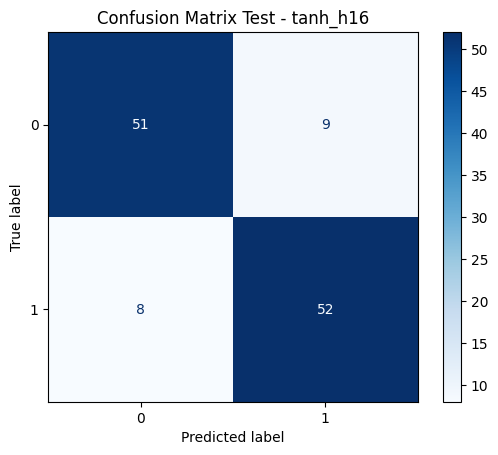

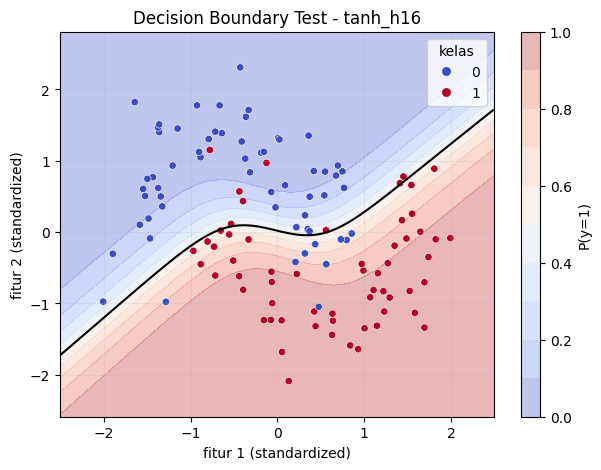

In [11]:
def plot_decision_boundary(model, X_values, y_values, title):
    # Mesh, prediksi probabilitas, contourf, batas 0.5, dan scatter data.
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 240), np.linspace(y_min, y_max, 240))
    grid_values = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(grid_values, device=DEVICE))
        probabilities = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7, 5))
    filled = ax.contourf(xx, yy, probabilities, levels=np.linspace(0, 1, 11),
                         cmap='coolwarm', alpha=0.35)
    ax.contour(xx, yy, probabilities, levels=[0.5], colors='black', linewidths=1.5)
    scatter = ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap='coolwarm',
                         edgecolor='white', linewidth=0.4, s=28)
    ax.set(title=title, xlabel='fitur 1 (standardized)', ylabel='fitur 2 (standardized)')
    ax.grid(alpha=0.2)
    ax.legend(*scatter.legend_elements(), title='kelas')
    fig.colorbar(filled, ax=ax, label='P(y=1)')
    plt.show()

# Ambil run_id terbaik dari results.
best_run = results.iloc[0]['run_id']
final_model = trained_models[best_run]

# Hitung test loss dan test accuracy satu kali.
final_test_metrics = evaluate(final_model, X_test_t, y_test_t)
results.loc[results['run_id'] == best_run, 'test_metric'] = final_test_metrics['accuracy']
results.to_csv(f'M01_{NIM}_metrics.csv', index=False)
print(f'Model final dipilih dari validation loss: {best_run}')
print(f"Test loss={final_test_metrics['loss']:.4f}, test accuracy={final_test_metrics['accuracy']:.4f}")

# Confusion matrix dan decision boundary model final.
cm = confusion_matrix(y_test, final_test_metrics['predictions'])
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title(f'Confusion Matrix Test - {best_run}')
plt.show()
plot_decision_boundary(final_model, X_test_s, y_test, f'Decision Boundary Test - {best_run}')

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? Tidak selalu, walaupun pada eksperimen ini ketiga aktivasi memang membaik saat hidden size dinaikkan dari 4 ke 16. Besar perbaikannya sangat berbeda: tanh turun dari 0,2887 ke 0,2056, ReLU dari 0,2720 ke 0,2268, sedangkan sigmoid hanya dari 0,2952 ke 0,2900. Kapasitas tambahan membantu bila aktivasinya mampu memanfaatkannya, tetapi hasil ini hanya dari satu seed dan dua ukuran, sehingga belum membuktikan bahwa hidden size lebih besar selalu lebih baik.
2. Aktivasi mana yang paling stabil pada dua hidden size? Bila stabil diartikan hasilnya paling sedikit berubah antara h=4 dan h=16, sigmoid paling stabil (selisih validation loss hanya 0,0052), tetapi sigmoid juga konsisten paling buruk. Tanh paling sensitif terhadap hidden size (selisih 0,0831) namun memberi hasil terbaik pada h=16. ReLU berada di tengah (selisih 0,0452) dan menjadi yang terbaik pada h=4 (0,2720).
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? Ada. `sigmoid_h4` dan `sigmoid_h16` sama-sama memiliki validation accuracy 0,8833, tetapi BCE-nya 0,2952 dan 0,2900. Hal serupa terlihat pada `relu_h16` dan baseline `relu_h8` (accuracy 0,9167, BCE 0,2268 vs 0,2346). Accuracy hanya menghitung benar/salah setelah threshold 0,5, sedangkan BCE juga memperhitungkan seberapa yakin probabilitasnya, sehingga prediksi benar yang lebih yakin dan prediksi salah yang kurang yakin menurunkan BCE tanpa mengubah accuracy.
4. Di bagian mana decision boundary paling tidak pasti? Di sekitar garis kontur probabilitas 0,5, terutama pada celah di antara dua bulan dan di ujung masing-masing bulan tempat titik kedua kelas saling tumpang tindih akibat noise 0,22. Di area tersebut warna latar mendekati netral dan sebagian besar kesalahan test berada di sana.
5. Apa satu keterbatasan eksperimen ini? Eksperimen hanya memakai satu dataset sintetis `make_moons` berukuran 600 titik, satu seed individual (1048), dan anggaran training tetap (SGD lr 0,05, 200 epoch). Peringkat aktivasi bisa berubah pada seed, learning rate, atau dataset lain.
6. Apakah hasil sesuai hipotesis awal? Sebagian sesuai. Hidden size 16 memang lebih baik daripada 4 untuk ketiga aktivasi, dan tanh memberi hasil terbaik (`tanh_h16`, validation loss 0,2056). Namun, sigmoid tidak kompetitif seperti yang saya duga karena justru paling buruk pada kedua ukuran. Model final `tanh_h16` menghasilkan test loss 0,3277 dan test accuracy 0,8583.

## Checklist pengumpulan - 5 poin reproduksibilitas

- [x] Identitas, seed, versi library, dan device tercantum.
- [x] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [x] Enam eksperimen tercatat pada notebook dan CSV.
- [x] Test set hanya dipakai untuk model final.
- [x] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [x] Notebook lolos Restart Kernel and Run All.
- [x] Tidak ada path absolut atau data pribadi.
- [x] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Fadil Alfarizzi, 2026-09-22